Environment Setup and Data setup

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pickle
import matplotlib.pyplot as plt
from google.colab import drive

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware selected: {device}")

BATCH_SIZE = 128
LR = 0.001
EPOCHS = 10
MAX_LEN = 100
STEP_SIZE = 10

print("\nMounting Drive...")
drive.mount('/content/drive')
base_path = '/content/drive/My Drive/resources/KuaiRec 2.0/data/processed/'

Hardware selected: cuda

Mounting Drive...
Mounted at /content/drive


Model+Class Redefine (Copied from Notebook 03)

In [ ]:
#Dataset
class SASRecDataset(Dataset):
  def __init__(self, sequences, max_len = 100, step_size = 10):
    self.data = []
    self.max_len = max_len

    for uid in sequences:
      full_seq = sequences[uid]['item_sequence']
      seq_len = len(full_seq)

      if seq_len <= max_len + 1:
        self.data.append(full_seq)
      else:
        for i in range(0, seq_len, step_size):
          chunk = full_seq[i : i + max_len + 1]

          if len(chunk) > 5:
            self.data.append(chunk)

  def __len__(self):
    return len(self.data)

  def __getitem__(self, index):
    seq = self.data[index]

    if len(seq) > self.max_len + 1:
      seq = seq[-(self.max_len + 1):]

    seq = [x + 1 for x in seq]

    pad_len = (self.max_len + 1) - len(seq)
    seq = [0] * pad_len + seq

    seq_tensor = torch.tensor(seq, dtype = torch.long)

    return {
        'input_seq': seq_tensor[:-1],
        'target_seq': seq_tensor[1:]
    }

#Model Engine
class SASRec(nn.Module):
  def __init__(
      self,
      frozen_item_vectors,
      max_seq_len = 50,
      embed_dim = 64,
      heads = 2,
      layers = 2,
      dropout = 0.1):

    super(SASRec, self).__init__()

    self.max_seq_len = max_seq_len
    self.embed_dim = embed_dim

    #padding for index 0
    pad_row = torch.zeros(1, embed_dim).to(frozen_item_vectors.device)
    full_matrix = torch.cat([pad_row, frozen_item_vectors], dim = 0)

    #frozen embeddings
    self.item_embedding = nn.Embedding.from_pretrained(full_matrix, freeze = True, padding_idx=0)

    #adapter?
    self.adapter = nn.Sequential(
        nn.Linear(embed_dim, 128),
        nn.ReLU(),
        nn.Linear(128, embed_dim)
    )

    #position embeddings
    self.pos_embedding = nn.Embedding(max_seq_len, embed_dim)

    #encoder
    self.encoder_layer = nn.TransformerEncoderLayer(
        d_model=embed_dim,
        nhead=heads,
        dim_feedforward=128,
        dropout=dropout,
        batch_first=True)
    self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=layers)

    #normalization
    self.norm = nn.LayerNorm(embed_dim)

    num_items_total = full_matrix.size(0)
    self.prediction_head = nn.Linear(embed_dim, num_items_total)

  def forward(self, item_seq):
    seq_len = item_seq.size(1)

    #input prep
    items_emb = self.item_embedding(item_seq)
    items_emb = self.adapter(items_emb)


    positions = torch.arange(seq_len, device = item_seq.device).unsqueeze(0)
    x = items_emb + self.pos_embedding(positions)

    #causal masking
    causal_mask = torch.triu(torch.ones(seq_len, seq_len, device = item_seq.device) * float('-inf'), diagonal = 1)
    padding_mask = (item_seq == 0)

    output = self.transformer_encoder(x, mask = causal_mask, src_key_padding_mask = padding_mask)
    output = self.norm(output)

    #prediction
    logits = self.prediction_head(output)

    return logits

Loading Data and Weights

In [ ]:
with open(base_path + 'train_sequence.pkl', 'rb') as f:
    full_data = pickle.load(f)

frozen_embeddings = np.load(base_path + 'frozen_item_embeddings.npy')
frozen_embeddings = torch.tensor(frozen_embeddings, dtype=torch.float32).to(device)

#FORGOTTEN_USER (COPIED FROM NOTEBOOK 03)
max_interactions = 0
FORGOTTEN_USER = -1
for uid, data in full_data.items():
    seq_len = len(data['item_sequence'])
    if seq_len > max_interactions:
        max_interactions = seq_len
        FORGOTTEN_USER = uid
print(f"Forgotten user: {FORGOTTEN_USER}")

#model initializing..
print("Initializing models....")
model_base = SASRec(frozen_embeddings, max_seq_len=MAX_LEN).to(device)
model_unlearned = SASRec(frozen_embeddings, max_seq_len=MAX_LEN).to(device)

#weights
print("Loading weights..")
try:
    model_base.load_state_dict(torch.load(base_path + 'baseline_model.pth', map_location=device))
    model_unlearned.load_state_dict(torch.load(base_path + 'unlearned_model.pth', map_location=device))

    with open(base_path + 'test_targets.pkl', 'rb') as f:
        test_targets = pickle.load(f)
    print(f"Test targets: {len(test_targets)}")

    print("ok")
except Exception as e:
    print(f"ERROR {e}")

model_base.eval()
model_unlearned.eval()
print("Models loaded.")

Forgotten user: 4247
Initializing models....
Loading weights..
Test targets: 7176
ok
Models loaded.


Evaluation utility+privacy

In [ ]:
import torch.nn.functional as F
import random

#UTILITY
#Can the model predict the FUTURE hidden item?
def calculate_utility(model, sequences, test_targets, user_list):
    model.eval()
    hits = 0
    count = 0

    with torch.no_grad():
        for uid in user_list:
            if uid not in test_targets or uid not in sequences:
                continue

            seq = sequences[uid]['item_sequence']

            if len(seq) > MAX_LEN:
                seq = seq[-MAX_LEN:]
            seq = [x + 1 for x in seq]
            pad_len = MAX_LEN - len(seq)
            seq = [0] * pad_len + seq

            input_tensor = torch.tensor([seq], dtype=torch.long).to(device)

            true_item = test_targets[uid]
            target_index = true_item + 1

            logits = model(input_tensor)
            last_logits = logits[0, -1, :]

            top_scores, top_indices = torch.topk(last_logits, k=10)
            top_indices = top_indices.cpu().tolist()

            if target_index in top_indices:
                hits += 1
            count += 1

    return hits / count if count > 0 else 0

#PRIVACY
#Did the model forgot the user?
def calculate_user_loss(model, sequences, user_id):
    model.eval()

    user_data = {user_id: sequences[user_id]}

    ds = SASRecDataset(user_data, max_len=MAX_LEN, step_size=5)
    dl = DataLoader(ds, batch_size=32, shuffle=False)

    total_loss = 0
    steps = 0
    criterion = torch.nn.CrossEntropyLoss(ignore_index=0, reduction='sum')

    with torch.no_grad():
        for batch in dl:
            input_seq = batch['input_seq'].to(device)
            target_seq = batch['target_seq'].to(device)

            #non-zero targets
            num_valid_items = (target_seq != 0).sum().item()

            if num_valid_items == 0:
                continue

            logits = model(input_seq)
            logits = logits.view(-1, logits.size(-1))
            targets = target_seq.view(-1)

            loss = criterion(logits, targets)

            if not torch.isnan(loss):
                total_loss += loss.item()
                steps += num_valid_items

    return total_loss / steps if steps > 0 else 0.0

execution

In [ ]:
print(f"UTILITY METRIC")

all_users = list(test_targets.keys())
if FORGOTTEN_USER in all_users:
  all_users.remove(FORGOTTEN_USER)

random.seed(42)
general_users = random.sample(all_users, 500)

print("Calculating Baseline Utility...")
util_base = calculate_utility(model_base, full_data, test_targets, general_users)

print("Calculating Unlearned Utility...")
util_unlearn = calculate_utility(model_unlearned, full_data, test_targets, general_users)

print(f"Baseline HR@10:  {util_base:.4f}")
print(f"Unlearned HR@10: {util_unlearn:.4f}")
print(f"Utility Drop:    {util_base - util_unlearn:.4f}")

print(f"PRIVACY METRIC for user {FORGOTTEN_USER}")

loss_base = calculate_user_loss(model_base, full_data, FORGOTTEN_USER)
loss_unlearn = calculate_user_loss(model_unlearned, full_data, FORGOTTEN_USER)

print(f"Baseline Loss:   {loss_base:.4f}")
print(f"Unlearned Loss:  {loss_unlearn:.4f}")
print(f"Privacy Gain:    {loss_unlearn - loss_base:.4f}")

UTILITY METRIC
Calculating Baseline Utility...
Calculating Unlearned Utility...
Baseline HR@10:  0.0240
Unlearned HR@10: 0.0260
Utility Drop:    -0.0020
PRIVACY METRIC for user 4247
Baseline Loss:   3.6130
Unlearned Loss:  8.3252
Privacy Gain:    4.7122


Visuals

Saved: final_utility_chart.png


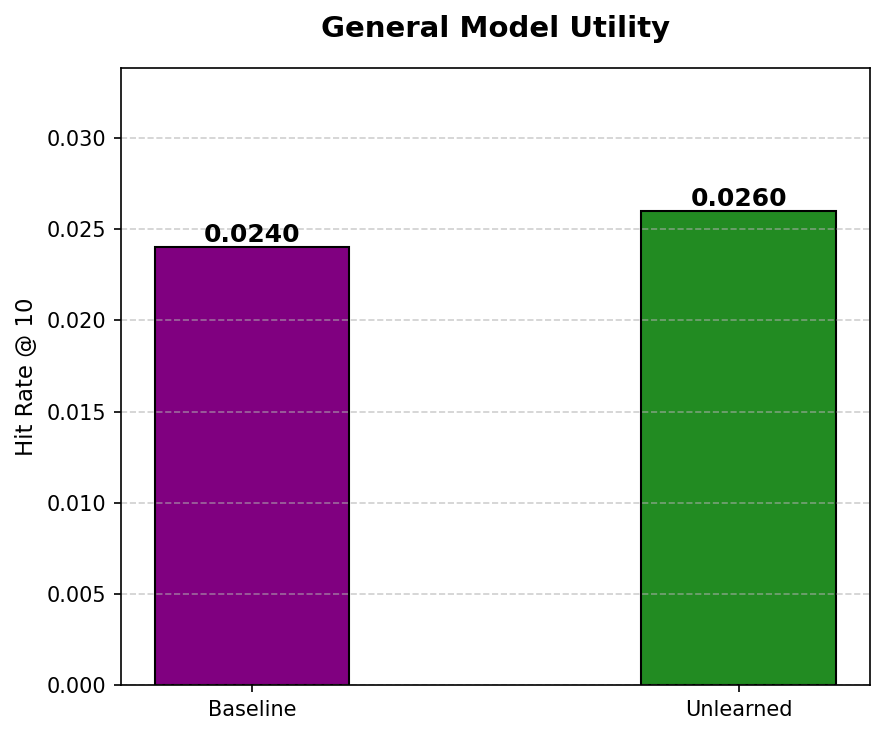

Saved: final_privacy_chart.png


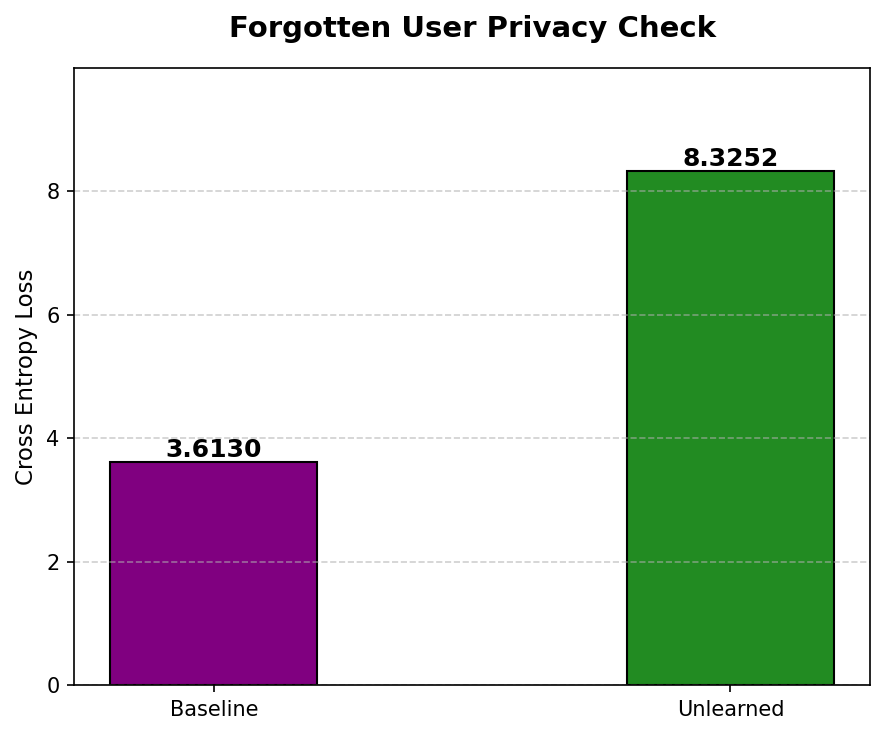

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

utility_values = [util_base, util_unlearn]
privacy_values = [loss_base, loss_unlearn]

labels = ['Baseline', 'Unlearned']
colors = ['purple', 'forestgreen']
bar_width = 0.4

#UTILITY (Hit Rate)
plt.figure(figsize=(6, 5), dpi=150)
bars = plt.bar(labels, utility_values,
               color=colors, width=bar_width, edgecolor='black', linewidth=1)

plt.title('General Model Utility', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Hit Rate @ 10', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.ylim(0, max(utility_values) * 1.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(base_path + 'final_utility_chart.png')
print("Saved: final_utility_chart.png")
plt.show()


#PRIVACY (Log Loss)
plt.figure(figsize=(6, 5), dpi=150)
bars = plt.bar(labels, privacy_values,
               color=colors, width=bar_width, edgecolor='black', linewidth=1)

plt.title(f'Forgotten User Privacy Check', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Cross Entropy Loss', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.ylim(0, max(privacy_values) * 1.2)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(base_path + 'final_privacy_chart.png')
print("Saved: final_privacy_chart.png")
plt.show()